# 🌾 Crop Recommendation — Data Analysis & Model Training

Colab-style notebook. Run cells top-to-bottom. All artifacts (model, scaler,
label encoder, metrics JSON, EDA plots, confusion matrix, feature importance)
are saved into the project's `model/` folder so the Flask app in `app.py`
can load them.

**Run locally:**
```bash
pip install -r ../requirements.txt jupyter
jupyter notebook data_analysis.ipynb
```

**Run in Google Colab:** upload this file and run all cells. Then download
the generated `model/` folder back into your project.


## 1. Imports & configuration

In [1]:
import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests, joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

# Resolve project root (notebook lives in crop-recommender/notebooks/)
NB_DIR   = Path.cwd()
ROOT     = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
DATA_DIR = ROOT / "dataset"
MODEL_DIR= ROOT / "model"
EDA_DIR  = MODEL_DIR / "eda"          # <- all plots live under model/eda
STATIC_EDA = ROOT / "static" / "images" / "eda"  # mirror for Flask app
for d in (DATA_DIR, MODEL_DIR, EDA_DIR, STATIC_EDA): d.mkdir(parents=True, exist_ok=True)
print("project root:", ROOT)


project root: c:\OPTICROP-AGRI


## 2. Download the dataset (auto-fallback across mirrors)

In [2]:
DATASET_PATH = DATA_DIR / "Crop_recommendation.csv"
MIRRORS = [
    "https://raw.githubusercontent.com/Gladiator07/Harvestify/master/Data-processed/crop_recommendation.csv",
    "https://raw.githubusercontent.com/gabbygab1233/Crop-Recommender/main/Crop_recommendation.csv",
    "https://raw.githubusercontent.com/arunperala/Modern-Farming-using-MachineLearning/main/Data-processed/crop_recommendation.csv",
]
if not DATASET_PATH.exists():
    for url in MIRRORS:
        try:
            print("→", url)
            r = requests.get(url, timeout=60); r.raise_for_status()
            head = r.content[:200].decode("utf-8","ignore").lower()
            assert "label" in head and "temperature" in head
            DATASET_PATH.write_bytes(r.content)
            print("  saved:", DATASET_PATH); break
        except Exception as e:
            print("  failed:", e)
    else:
        raise RuntimeError("All dataset mirrors failed. Download manually into ../dataset/")
else:
    print("dataset already present:", DATASET_PATH)


dataset already present: c:\OPTICROP-AGRI\dataset\Crop_recommendation.csv


## 3. Load & clean

In [3]:
FEATURES = ["N","P","K","temperature","humidity","ph","rainfall"]
df = pd.read_csv(DATASET_PATH)
df.columns = [c.strip() for c in df.columns]
for f in FEATURES: df[f] = pd.to_numeric(df[f], errors="coerce")
df["label"] = df["label"].astype(str).str.strip().str.lower()
df = df.drop_duplicates().dropna().reset_index(drop=True)
print("shape:", df.shape, "| classes:", df["label"].nunique())
df.head()


shape: (2200, 8) | classes: 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


In [5]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## 4. Exploratory Data Analysis
All plots are saved to `model/eda/` so the Research page in the Flask app can display them.

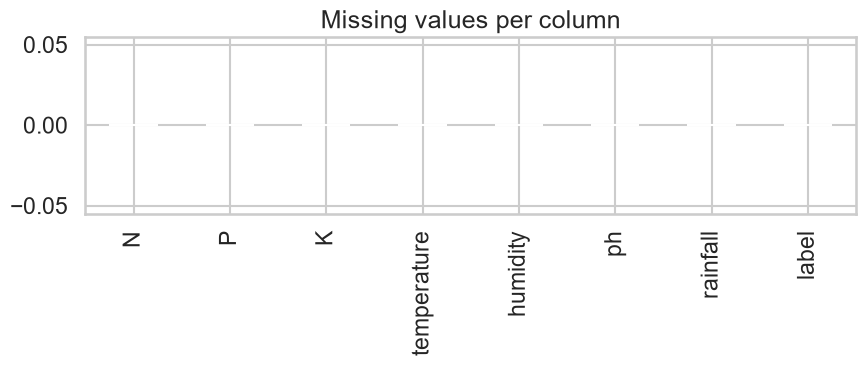

In [6]:
fig, ax = plt.subplots(figsize=(9,4))
df.isna().sum().plot(kind="bar", ax=ax, color="#0f3d2e")
ax.set_title("Missing values per column"); fig.tight_layout()
fig.savefig(EDA_DIR/"missing.png", dpi=140); plt.show()


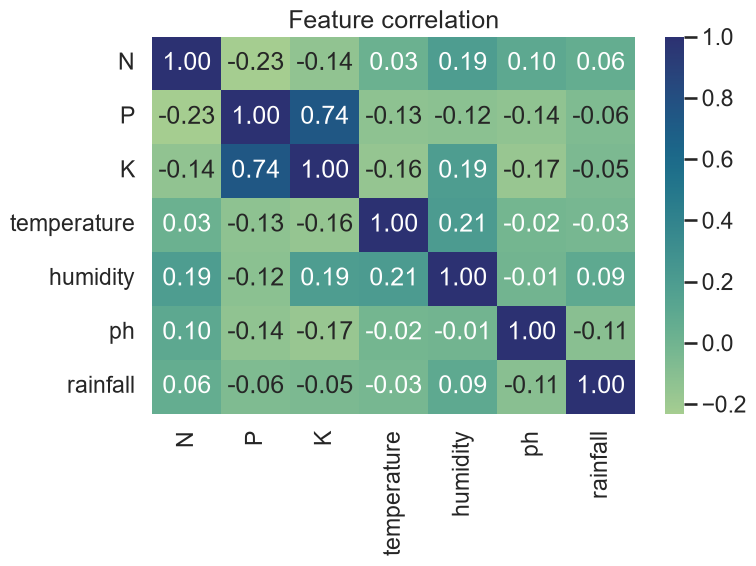

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="crest", ax=ax)
ax.set_title("Feature correlation"); fig.tight_layout()
fig.savefig(EDA_DIR/"correlation_heatmap.png", dpi=140); plt.show()


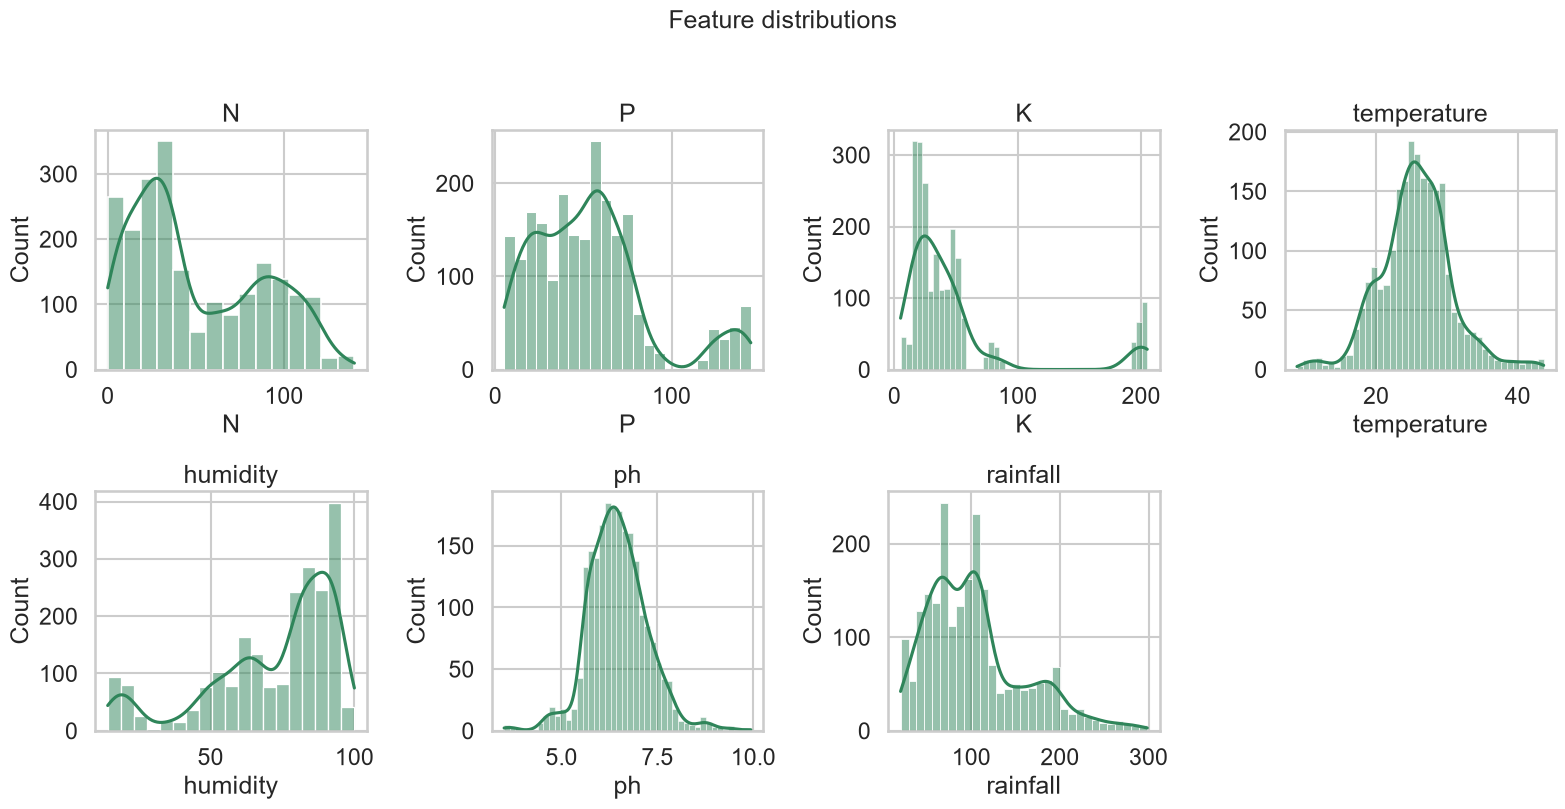

In [8]:
fig, axes = plt.subplots(2,4, figsize=(16,8))
for ax, col in zip(axes.flatten(), FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="#2f855a"); ax.set_title(col)
axes.flatten()[-1].axis("off")
fig.suptitle("Feature distributions", y=1.02, fontsize=18); fig.tight_layout()
fig.savefig(EDA_DIR/"histograms.png", dpi=140, bbox_inches="tight"); plt.show()


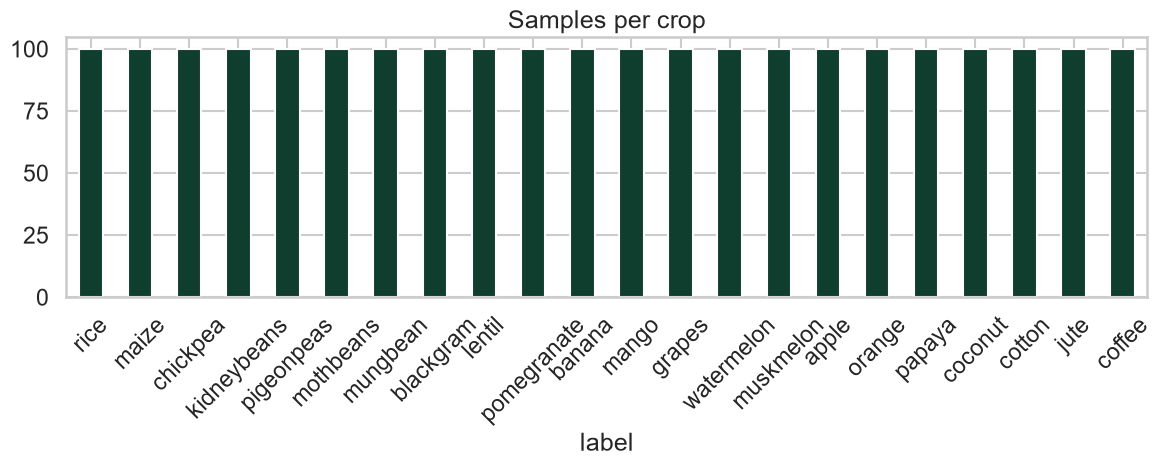

In [9]:
fig, ax = plt.subplots(figsize=(12,5))
df["label"].value_counts().plot(kind="bar", ax=ax, color="#0f3d2e")
ax.set_title("Samples per crop"); ax.tick_params(axis="x", rotation=45); fig.tight_layout()
fig.savefig(EDA_DIR/"class_balance.png", dpi=140); plt.show()


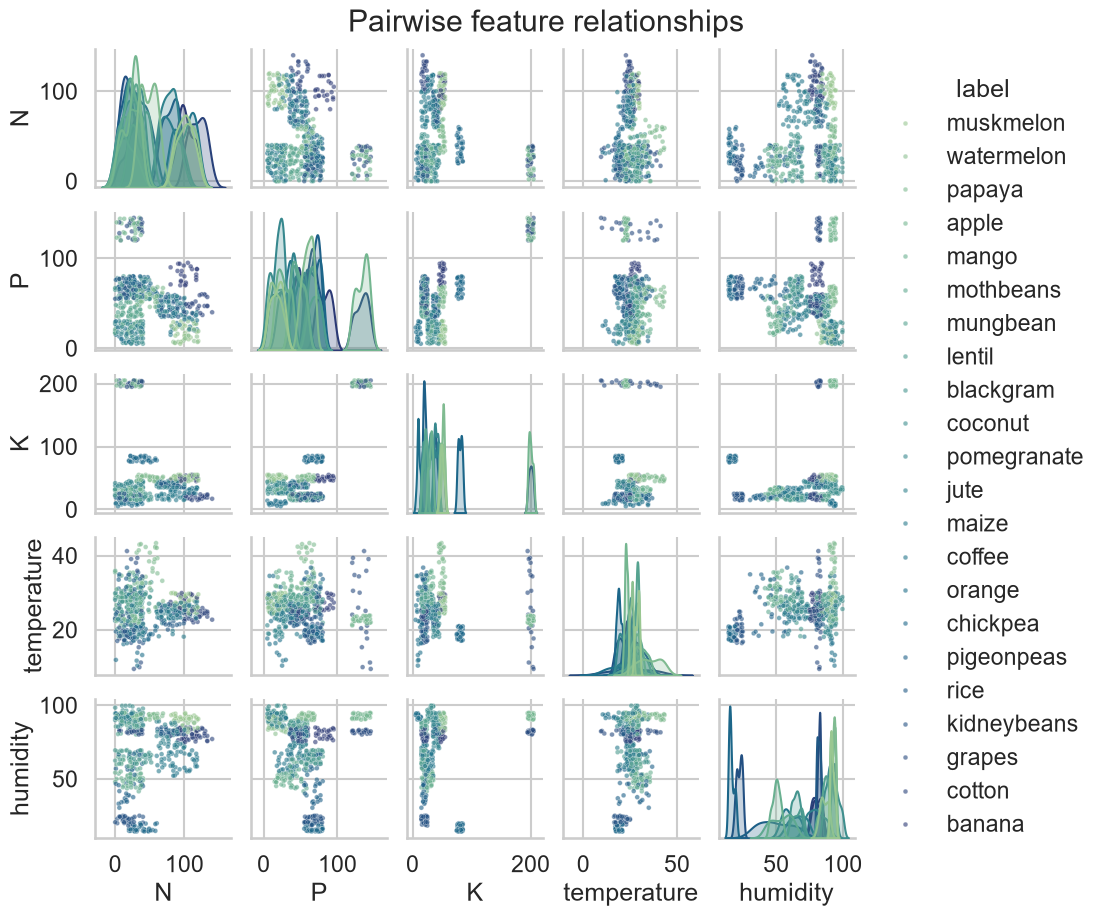

In [10]:
sample = df.sample(min(600, len(df)), random_state=42)
g = sns.pairplot(sample, vars=FEATURES[:5], hue="label", palette="crest",
                 plot_kws={"s":12,"alpha":0.6}, height=1.8)
g.fig.suptitle("Pairwise feature relationships", y=1.02)
g.fig.savefig(EDA_DIR/"pairplot.png", dpi=120, bbox_inches="tight"); plt.show()


## 5. Preprocess: scale + encode + split

In [11]:
X = df[FEATURES].values
y_raw = df["label"].values
le = LabelEncoder(); y = le.fit_transform(y_raw)
scaler = StandardScaler(); Xs = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y, test_size=0.2, stratify=y, random_state=42)
print("train:", X_train.shape, "test:", X_test.shape, "classes:", len(le.classes_))


train: (1760, 7) test: (440, 7) classes: 22


## 6. Train & compare 5 classifiers

In [12]:
candidates = {
    "RandomForest":       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "KNN":                KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVC":                SVC(kernel="rbf", C=2.0, probability=True, random_state=42),
    "GaussianNB":         GaussianNB(),
}
scores = {}; best_name=""; best_model=None; best_acc=-1
for name, m in candidates.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    scores[name] = round(float(acc), 4)
    print(f"  {name:20s} acc={acc:.4f}")
    if acc > best_acc: best_acc, best_name, best_model = acc, name, m
print("\n* best:", best_name, best_acc)


  RandomForest         acc=0.9932
  LogisticRegression   acc=0.9727
  KNN                  acc=0.9795
  SVC                  acc=0.9864
  GaussianNB           acc=0.9955

* best: GaussianNB 0.9954545454545455


## 7. Evaluate the best model

accuracy=0.9955  macro-F1=0.9954


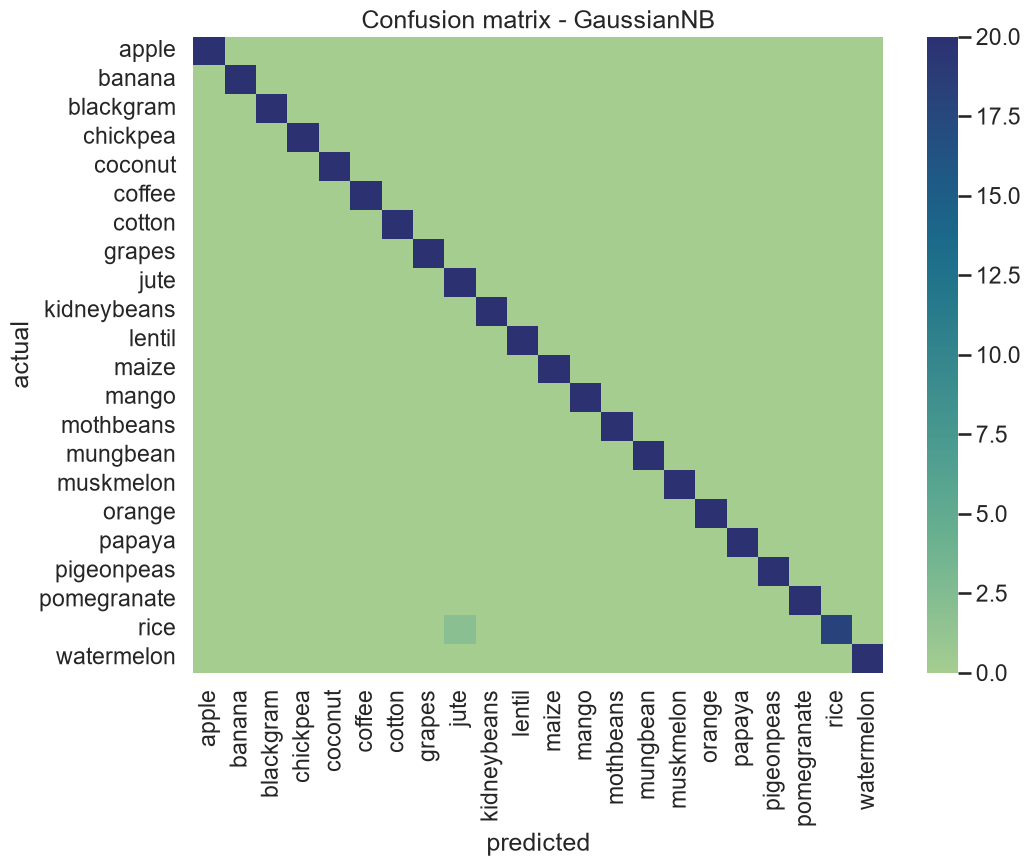

In [13]:
preds = best_model.predict(X_test)
macro_f1 = float(f1_score(y_test, preds, average="macro"))
report = classification_report(y_test, preds, target_names=list(le.classes_),
                               output_dict=True, zero_division=0)
cm = confusion_matrix(y_test, preds)
print(f"accuracy={best_acc:.4f}  macro-F1={macro_f1:.4f}")

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(cm, cmap="crest", xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f"Confusion matrix - {best_name}"); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
fig.tight_layout(); fig.savefig(EDA_DIR/"confusion_matrix.png", dpi=140); plt.show()


In [14]:
importance = None
if hasattr(best_model, "feature_importances_"):
    importance = np.asarray(best_model.feature_importances_, dtype=float)
elif hasattr(best_model, "coef_"):
    importance = np.abs(np.asarray(best_model.coef_, dtype=float)).mean(axis=0)

if importance is not None:
    order = np.argsort(importance)[::-1]
    fig, ax = plt.subplots(figsize=(9,4.5))
    ax.bar(np.array(FEATURES)[order], importance[order], color="#0f3d2e")
    ax.set_title(f"Feature importance - {best_name}"); fig.tight_layout()
    fig.savefig(EDA_DIR/"feature_importance.png", dpi=140); plt.show()


## 8. Persist artifacts into `model/`
`app.py` loads these three joblib files at startup.

In [15]:
joblib.dump(best_model, MODEL_DIR/"crop_model.joblib")
joblib.dump(scaler,     MODEL_DIR/"scaler.joblib")
joblib.dump(le,         MODEL_DIR/"label_encoder.joblib")

metrics = {
    "best_model": best_name,
    "accuracy": round(float(best_acc), 4),
    "macro_f1": round(macro_f1, 4),
    "model_scores": scores,
    "classes": list(le.classes_),
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
    "feature_importance": ({f: float(v) for f, v in zip(FEATURES, importance)}
                           if importance is not None else None),
    "n_samples": int(len(df)),
    "n_features": len(FEATURES),
    "n_classes": int(len(le.classes_)),
}
(MODEL_DIR/"metrics.json").write_text(json.dumps(metrics, indent=2))
print("saved to", MODEL_DIR)
for p in sorted(MODEL_DIR.rglob("*")): print(" ", p.relative_to(MODEL_DIR))


saved to c:\OPTICROP-AGRI\model
  crop_model.joblib
  eda
  eda\class_balance.png
  eda\confusion_matrix.png
  eda\correlation_heatmap.png
  eda\histograms.png
  eda\missing.png
  eda\pairplot.png
  label_encoder.joblib
  metrics.json
  scaler.joblib


## 9. Sanity-check prediction

In [16]:
sample = np.array([[90, 42, 43, 20.9, 82.0, 6.5, 202.9]])   # rice-like inputs
proba = best_model.predict_proba(scaler.transform(sample))[0]
top3 = np.argsort(proba)[::-1][:3]
for i in top3: print(f"  {le.classes_[i]:15s} {proba[i]*100:5.2f}%")


  rice            99.48%
  jute             0.52%
  coffee           0.00%


In [17]:
import shutil
# Mirror EDA plots into static/images/eda/ so the Flask Research page shows them
for f in EDA_DIR.glob("*.png"):
    shutil.copy2(f, STATIC_EDA / f.name)
print("mirrored to", STATIC_EDA)


mirrored to c:\OPTICROP-AGRI\static\images\eda


---
**Done.** Restart the Flask app (`python app.py`) - it will now use the freshly trained model.